# Simple CNN Baseline

Trains a small CNN end-to-end on the same preprocessed grayscale 128x128 inputs used by the classical pipeline. Serves as an exploratory probe of how much discriminative signal is learnable directly from pixel intensities, before any feature engineering. Preprocessing (deduplication, grayscale, 128x128 Lanczos resize, [0,1] normalization) and train/val/test partitioning are kept identical to the main notebook so this baseline is genuinely comparable to the classical pipeline.

In [1]:
import os
import time
import hashlib
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


## Data loading (identical to main pipeline)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_labels = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
img_size = 128

dir = '/content/drive/MyDrive/281/data'
train_dir = os.path.join(dir, 'Training')
test_dir = os.path.join(dir, 'Testing')

def det_hash(filpath):
    ha = hashlib.md5()
    with open(filpath, 'rb') as f:
        ha.update(f.read())
    return ha.hexdigest()

def get_unique_filepaths(train_dir, test_dir, classes):
    seen_hashes = set()
    train_paths_by_class = {cls: [] for cls in classes}
    test_paths_by_class = {cls: [] for cls in classes}
    within_train_dups = within_test_dups = cross_split_dups = 0

    for cls in classes:
        cls_dir = os.path.join(train_dir, cls)
        for filname in sorted(os.listdir(cls_dir)):
            filpath = os.path.join(cls_dir, filname)
            h = det_hash(filpath)
            if h in seen_hashes:
                within_train_dups += 1
            else:
                seen_hashes.add(h)
                train_paths_by_class[cls].append(filpath)

    test_seen_hashes = set()
    for cls in classes:
        cls_dir = os.path.join(test_dir, cls)
        for fname in sorted(os.listdir(cls_dir)):
            filpath = os.path.join(cls_dir, fname)
            h = det_hash(filpath)
            if h in seen_hashes:
                cross_split_dups += 1
            elif h in test_seen_hashes:
                within_test_dups += 1
            else:
                test_seen_hashes.add(h)
                test_paths_by_class[cls].append(filpath)

    print(f'train duplicates removed: {within_train_dups}')
    print(f'test duplicates removed:  {within_test_dups}')
    print(f'train-test cross over duplicates removed from test: {cross_split_dups}')
    return train_paths_by_class, test_paths_by_class

def load_images_from_paths(paths_by_class, classes, img_size=img_size):
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        for filpath in paths_by_class[cls]:
            img = Image.open(filpath).convert('L')
            img = img.resize((img_size, img_size), Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0
            images.append(arr)
            labels.append(label_idx)
    return np.array(images), np.array(labels)

train_paths_by_class, test_paths_by_class = get_unique_filepaths(train_dir, test_dir, classes)

t0 = time.time()
X_all, y_all = load_images_from_paths(train_paths_by_class, classes)
print(f'loaded {len(X_all)} unique training images in {time.time()-t0:.1f}s')

t0 = time.time()
X_test_raw, y_test = load_images_from_paths(test_paths_by_class, classes)
print(f'loaded {len(X_test_raw)} unique test images in {time.time()-t0:.1f}s')

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f'\nsplit: train={len(X_train_raw)}, val={len(X_val_raw)}, test={len(X_test_raw)}')
print('class distribution for training:', {classes[i]: int(np.sum(y_train == i)) for i in range(4)})

Mounted at /content/drive
train duplicates removed: 171
test duplicates removed:  16
train-test cross over duplicates removed from test: 0
loaded 5429 unique training images in 24.8s
loaded 1584 unique test images in 6.9s

split: train=4343, val=1086, test=1584
class distribution for training: {'glioma': 1120, 'meningioma': 1109, 'notumor': 1025, 'pituitary': 1089}


## PyTorch dataset and loaders

Inputs already normalized to [0,1] grayscale; we just add a channel dimension and wrap in tensors. No further preprocessing inside the loader to keep parity with the classical pipeline inputs.

In [3]:
class MRIDataset(Dataset):
    def __init__(self, images, labels):
        # add channel dim: (N, H, W) -> (N, 1, H, W)
        self.images = torch.from_numpy(images).unsqueeze(1).float()
        self.labels = torch.from_numpy(labels).long()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.images[i], self.labels[i]

BATCH = 64
g = torch.Generator(); g.manual_seed(SEED)

train_loader = DataLoader(MRIDataset(X_train_raw, y_train), batch_size=BATCH, shuffle=True, generator=g, num_workers=2)
val_loader   = DataLoader(MRIDataset(X_val_raw,   y_val),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(MRIDataset(X_test_raw,  y_test),  batch_size=BATCH, shuffle=False, num_workers=2)

print(f'batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

batches: train=68, val=17, test=25


## Model: minimal 3-conv-block CNN

Three Conv-ReLU-MaxPool blocks (16 -> 32 -> 64 channels) followed by a small FC head. ~100k parameters; a deliberately small baseline rather than a competitor to ResNet-18.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        # Input: (B, 1, 128, 128)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # -> 128
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # -> 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> 32
        self.pool = nn.MaxPool2d(2, 2)
        # After 3 pools: 128 -> 64 -> 32 -> 16; final feature map: 64 x 16 x 16
        self.fc1 = nn.Linear(64 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, n_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN(n_classes=4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'params: {n_params:,}')

params: 1,072,196


## Training with early stopping on validation loss

In [5]:
EPOCHS = 20
LR = 1e-3
PATIENCE = 4   # stop if val loss does not improve for this many consecutive epochs

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss = total_correct = total_n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_state = None
epochs_since_improve = 0
stopped_epoch = EPOCHS

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

    improved = vl_loss < best_val_loss - 1e-4
    if improved:
        best_val_loss = vl_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    flag = ' *' if improved else ''
    print(f'epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {vl_loss:.4f} acc {vl_acc:.4f}{flag}')

    if epochs_since_improve >= PATIENCE:
        stopped_epoch = epoch
        print(f'early stopping triggered at epoch {epoch} (no val-loss improvement for {PATIENCE} epochs)')
        break

print(f'\ntraining time: {time.time()-t0:.1f}s')
model.load_state_dict(best_state)

epoch  1 | train loss 0.9331 acc 0.6102 | val loss 0.6078 acc 0.7643 *
epoch  2 | train loss 0.6321 acc 0.7465 | val loss 0.5202 acc 0.8158 *
epoch  3 | train loss 0.5265 acc 0.8008 | val loss 0.4320 acc 0.8324 *
epoch  4 | train loss 0.4441 acc 0.8259 | val loss 0.4236 acc 0.8269 *
epoch  5 | train loss 0.3978 acc 0.8480 | val loss 0.3916 acc 0.8582 *
epoch  6 | train loss 0.3442 acc 0.8678 | val loss 0.3629 acc 0.8490 *
epoch  7 | train loss 0.3066 acc 0.8777 | val loss 0.3508 acc 0.8600 *
epoch  8 | train loss 0.2719 acc 0.8902 | val loss 0.3041 acc 0.8886 *
epoch  9 | train loss 0.2377 acc 0.9084 | val loss 0.3033 acc 0.8913 *
epoch 10 | train loss 0.2046 acc 0.9196 | val loss 0.2677 acc 0.9061 *
epoch 11 | train loss 0.1916 acc 0.9210 | val loss 0.2715 acc 0.9052
epoch 12 | train loss 0.1673 acc 0.9376 | val loss 0.3209 acc 0.8748
epoch 13 | train loss 0.1434 acc 0.9431 | val loss 0.2808 acc 0.9079
epoch 14 | train loss 0.1311 acc 0.9514 | val loss 0.3056 acc 0.9033
early stopping

<All keys matched successfully>

## Training curves

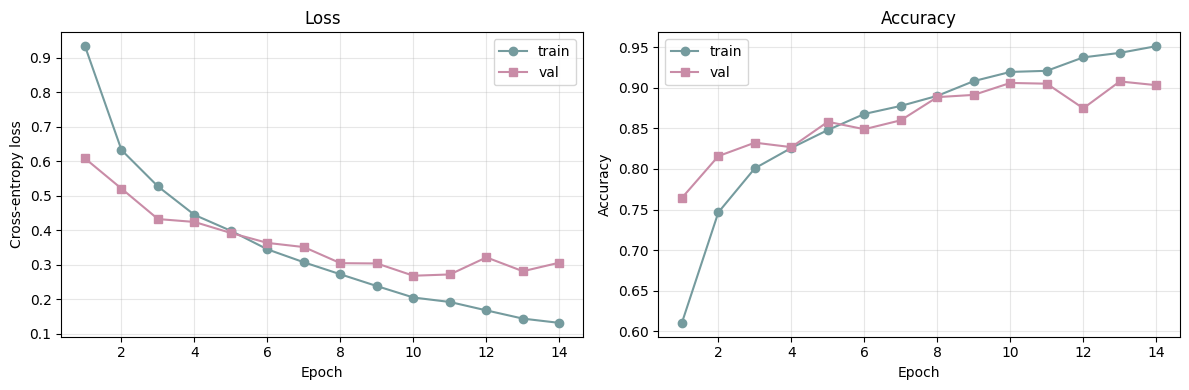

In [6]:
epochs_run = list(range(1, len(history['train_loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_run, history['train_loss'], 'o-', label='train', color='#759b9e')
axes[0].plot(epochs_run, history['val_loss'],   's-', label='val',   color='#c98ca7')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_run, history['train_acc'], 'o-', label='train', color='#759b9e')
axes[1].plot(epochs_run, history['val_acc'],   's-', label='val',   color='#c98ca7')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Test set evaluation

In [7]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(yb.numpy())
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)

test_acc = accuracy_score(y_true, y_pred)
print(f'test accuracy: {test_acc:.4f}\n')
print(classification_report(y_true, y_pred, target_names=class_labels, digits=3))

test accuracy: 0.8466

              precision    recall  f1-score   support

      Glioma      0.848     0.723     0.780       386
  Meningioma      0.807     0.746     0.775       398
    No Tumor      0.800     0.988     0.884       400
   Pituitary      0.941     0.925     0.933       400

    accuracy                          0.847      1584
   macro avg      0.849     0.845     0.843      1584
weighted avg      0.849     0.847     0.844      1584



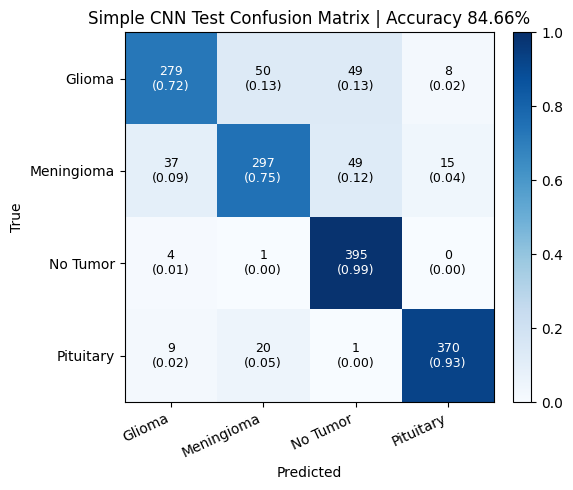

In [8]:
# Confusion matrix (counts + row-normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(class_labels, rotation=25, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(class_labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Simple CNN Test Confusion Matrix | Accuracy {test_acc*100:.2f}%')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.2f})',
                ha='center', va='center', fontsize=9,
                color='white' if cm_norm[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()